In [1]:
pip install pandas numpy openpyxl matplotlib scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
file_path = "Dissertation Excel.xlsx"

employee_df = pd.read_excel(file_path, sheet_name="Employee Data")
course_df = pd.read_excel(file_path, sheet_name="Courses")

In [4]:
employee_df.head()

,employee_id,current_role,experience_years,current_skills,desired_role,required_skills,skill_gap
0,E001,HR Assistant,2,"Excel, Communication",HR Executive,"Recruitment, Communication, Employee Engagement","Recruitment, Employee Engagement"
1,E002,HR Executive,4,"Communication, Recruitment",HR Manager,"HR Analytics, Leadership, Communication, Recru...","HR Analytics, Leadership"
2,E003,Talent Acquisition Coordinator,3,"Recruitment, Communication",Talent Acquisition Lead,"Recruitment, Stakeholder Management, Communica...",Stakeholder Management
3,E004,Finance Assistant,2,"Accounting, Excel",Financial Analyst,"Excel, Accounting, Budgeting, Financial Reporting","Budgeting, Financial Reporting"
4,E005,Financial Executive,5,"Payroll, Accounting",Finance Lead,"Financial Reporting, Budgeting, Leadership","Financial Reporting, Budgeting, Leadership"


In [5]:
course_df.head()

,skill,recommended_course
0,Recruitment,Recruitment Fundamentals
1,Employee Engagement,Employee Engagement Essentials
2,HR Analytics,HR Analytics Essentials
3,Leadership,Leadership Fundamentals
4,Stakeholder Management,Stakeholder Management Essentials


In [6]:
print(employee_df.columns)
print(course_df.columns)

Index(['employee_id', 'current_role', 'experience_years', 'current_skills',
       'desired_role', 'required_skills', 'skill_gap'],
      dtype='str')
Index(['skill', 'recommended_course'], dtype='str')


In [7]:
def clean_skill_list(skill_text):
    if pd.isna(skill_text):
        return []
    
    return [
        skill.strip().lower()
        for skill in str(skill_text).split(",")
        if skill.strip() != ""
    ]

In [8]:
def find_skill_gap(current_skills, required_skills):
    current = set(clean_skill_list(current_skills))
    required = set(clean_skill_list(required_skills))
    
    missing = required - current
    
    if len(missing) == 0:
        return "No skill gap"
    
    return ", ".join([skill.title() for skill in sorted(missing)])

In [9]:
def calculate_match_score(current_skills, required_skills):
    current = set(clean_skill_list(current_skills))
    required = set(clean_skill_list(required_skills))
    
    if len(required) == 0:
        return 0
    
    matched = current.intersection(required)
    score = (len(matched) / len(required)) * 100
    
    return round(score, 2)

In [10]:
course_mapping = dict(
    zip(
        course_df["skill"].str.lower().str.strip(),
        course_df["recommended_course"]
    )
)

In [11]:
def recommend_courses(skill_gap):
    if skill_gap == "No skill gap":
        return "No additional course required. Employee is ready to apply for this role."
    
    missing_skills = clean_skill_list(skill_gap)
    recommendations = []
    
    for skill in missing_skills:
        course = course_mapping.get(skill)
        
        if course:
            recommendations.append(course)
        else:
            recommendations.append(f"No mapped course found for {skill.title()}")
    
    return ", ".join(recommendations)

In [12]:
employee_df["generated_skill_gap"] = employee_df.apply(
    lambda row: find_skill_gap(row["current_skills"], row["required_skills"]),
    axis=1
)

employee_df["match_score"] = employee_df.apply(
    lambda row: calculate_match_score(row["current_skills"], row["required_skills"]),
    axis=1
)

employee_df["recommended_courses"] = employee_df["generated_skill_gap"].apply(recommend_courses)

In [13]:
def readiness_status(score):
    if score >= 80:
        return "Ready for Internal Transition"
    elif score >= 50:
        return "Needs Moderate Upskilling"
    else:
        return "Needs Significant Upskilling"

In [14]:
employee_df["readiness_status"] = employee_df["match_score"].apply(readiness_status)

In [15]:
final_output = employee_df[
    [
        "employee_id",
        "current_role",
        "experience_years",
        "current_skills",
        "desired_role",
        "required_skills",
        "generated_skill_gap",
        "match_score",
        "recommended_courses",
        "readiness_status"
    ]
]

final_output.head(10)

,employee_id,current_role,experience_years,current_skills,desired_role,required_skills,generated_skill_gap,match_score,recommended_courses,readiness_status
0,E001,HR Assistant,2,"Excel, Communication",HR Executive,"Recruitment, Communication, Employee Engagement","Employee Engagement, Recruitment",33.33,"Employee Engagement Essentials, Recruitment Fu...",Needs Significant Upskilling
1,E002,HR Executive,4,"Communication, Recruitment",HR Manager,"HR Analytics, Leadership, Communication, Recru...","Hr Analytics, Leadership",50.00,"HR Analytics Essentials, Leadership Fundamentals",Needs Moderate Upskilling
2,E003,Talent Acquisition Coordinator,3,"Recruitment, Communication",Talent Acquisition Lead,"Recruitment, Stakeholder Management, Communica...",Stakeholder Management,66.67,Stakeholder Management Essentials,Needs Moderate Upskilling
3,E004,Finance Assistant,2,"Accounting, Excel",Financial Analyst,"Excel, Accounting, Budgeting, Financial Reporting","Budgeting, Financial Reporting",50.00,"Budget Planning Essentials, Financial Reportin...",Needs Moderate Upskilling
4,E005,Financial Executive,5,"Payroll, Accounting",Finance Lead,"Financial Reporting, Budgeting, Leadership","Budgeting, Financial Reporting, Leadership",0.00,"Budget Planning Essentials, Financial Reportin...",Needs Significant Upskilling
5,E006,Marketing Executive,3,"Budgeting, Communication",Operations Analyst,"Excel, Process Improvement, Data Analysis","Data Analysis, Excel, Process Improvement",0.00,"Data Analysis Fundamentals, Advanced Excel for...",Needs Significant Upskilling
6,E007,Digital Marketing Assistant,2,"SQL, SEO",Marketing Lead,"SEO, Google Analytics, Leadership, Communication","Communication, Google Analytics, Leadership",25.00,"Business Communication Skills, Google Analytic...",Needs Significant Upskilling
7,E008,IT Support Analyst,4,"Python, Problem Solving",IT Engineer,"Python, SQL, Problem Solving, System Administr...","Sql, System Administration",50.00,"SQL for Analytics, System Administration Funda...",Needs Moderate Upskilling
8,E009,Business Systems Assistant,3,"Power BI, SQL",Business Analyst,"Business Analysis, SQL, Communication, Problem...","Business Analysis, Communication, Problem Solving",25.00,"Business Analysis Fundamentals, Business Commu...",Needs Significant Upskilling
9,E010,Operations Coordinator,5,"Tableau, Excel",Operations Manager,"Leadership, Project Management, Process Improv...","Leadership, Process Improvement, Project Manag...",0.00,"Leadership Fundamentals, Process Improvement E...",Needs Significant Upskilling


In [16]:
final_output.to_excel("final_ai_recommendation_output.xlsx", index=False)

print("Final AI recommendation output saved successfully.")

Final AI recommendation output saved successfully.


In [17]:
print("Total Employees:", len(final_output))
print("Average Match Score:", round(final_output["match_score"].mean(), 2))
print("Highest Match Score:", final_output["match_score"].max())
print("Lowest Match Score:", final_output["match_score"].min())

Total Employees: 50
Average Match Score: 38.7
Highest Match Score: 66.67
Lowest Match Score: 0.0


In [18]:
final_output["readiness_status"].value_counts()

readiness_status
Needs Significant Upskilling    30
Needs Moderate Upskilling       20
Name: count, dtype: int64

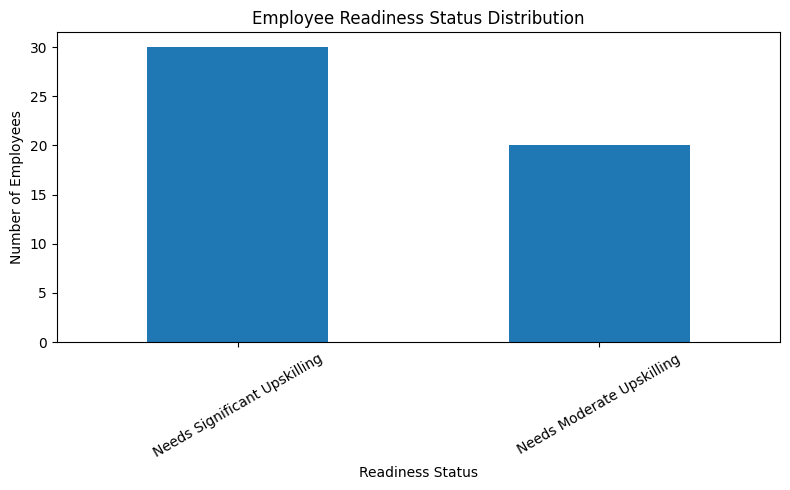

In [19]:
readiness_counts = final_output["readiness_status"].value_counts()

plt.figure(figsize=(8, 5))
readiness_counts.plot(kind="bar")
plt.title("Employee Readiness Status Distribution")
plt.xlabel("Readiness Status")
plt.ylabel("Number of Employees")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [20]:
employee_id = "E001"

final_output[final_output["employee_id"] == employee_id]

,employee_id,current_role,experience_years,current_skills,desired_role,required_skills,generated_skill_gap,match_score,recommended_courses,readiness_status
0,E001,HR Assistant,2,"Excel, Communication",HR Executive,"Recruitment, Communication, Employee Engagement","Employee Engagement, Recruitment",33.33,"Employee Engagement Essentials, Recruitment Fu...",Needs Significant Upskilling


In [21]:
top_candidates = final_output.sort_values(by="match_score", ascending=False)

top_candidates[
    [
        "employee_id",
        "current_role",
        "desired_role",
        "match_score",
        "readiness_status"
    ]
].head(10)

,employee_id,current_role,desired_role,match_score,readiness_status
16,E017,Executive Assistant,Executive Assistant,66.67,Needs Moderate Upskilling
2,E003,Talent Acquisition Coordinator,Talent Acquisition Lead,66.67,Needs Moderate Upskilling
17,E018,Product Owner,Product Owner,66.67,Needs Moderate Upskilling
37,E038,Research Analyst,Research Scientist,66.67,Needs Moderate Upskilling
41,E042,Operations Manager,Operations Manager,66.67,Needs Moderate Upskilling
38,E039,Logistics Partner,Logistics Lead,66.67,Needs Moderate Upskilling
26,E027,Network Engineer,Network Analyst,66.67,Needs Moderate Upskilling
30,E031,Secretary,Senior Secretary,66.67,Needs Moderate Upskilling
45,E046,Marketing Executive,Digital Marketing Analyst,66.67,Needs Moderate Upskilling
43,E044,HR Assistant,HR Executive,66.67,Needs Moderate Upskilling


In [22]:
low_match_employees = final_output.sort_values(by="match_score", ascending=True)

low_match_employees[
    [
        "employee_id",
        "current_role",
        "desired_role",
        "generated_skill_gap",
        "match_score",
        "recommended_courses"
    ]
].head(10)

,employee_id,current_role,desired_role,generated_skill_gap,match_score,recommended_courses
5,E006,Marketing Executive,Operations Analyst,"Data Analysis, Excel, Process Improvement",0.0,"Data Analysis Fundamentals, Advanced Excel for..."
4,E005,Financial Executive,Finance Lead,"Budgeting, Financial Reporting, Leadership",0.0,"Budget Planning Essentials, Financial Reportin..."
10,E011,Customer Support Executive,Operations Analyst,"Data Analysis, Excel, Process Improvement",0.0,"Data Analysis Fundamentals, Advanced Excel for..."
9,E010,Operations Coordinator,Operations Manager,"Leadership, Process Improvement, Project Manag...",0.0,"Leadership Fundamentals, Process Improvement E..."
22,E023,Data Analyst,Product Owner,"Agile, Project Management, Stakeholder Management",0.0,"Agile Project Management, Project Management E..."
18,E019,Operations Lead,Operations Manager,"Leadership, Process Improvement, Project Manag...",0.0,"Leadership Fundamentals, Process Improvement E..."
44,E045,Junior Data Analyst,Data Analyst,"Power Bi, Python, Sql, Statistics",20.0,"Power BI Dashboarding, Python Basics, SQL for ..."
12,E013,Business Analyst Associate,Business Analyst,"Business Analysis, Communication, Problem Solving",25.0,"Business Analysis Fundamentals, Business Commu..."
27,E028,UI/UX Intern,UI/UX Designer,"Figma, User Research, Wireframing",25.0,"Figma for UX Design, User Research Basics, Wir..."
19,E020,Marketing Manager,Marketing Lead,"Communication, Google Analytics, Leadership",25.0,"Business Communication Skills, Google Analytic..."
